# Train plant diseases detection

## Importing Libraries

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train', # directory 
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 69768 files belonging to 38 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [5]:
# x, y 
for x, y in training_set:
    print("x : " , x , x.shape)
    print("y : " , y , y.shape)
    break

    # x: images: 
    # shape=(32, 128, 128, 3), dtype=float32) (32, 128, 128, 3)
    # y : Classes: 
    # shape=(32, 38), dtype=float32) (32, 38)

x :  tf.Tensor(
[[[[180.   170.   160.  ]
   [184.   174.   164.  ]
   [187.25 177.25 167.25]
   ...
   [184.5  174.5  162.5 ]
   [184.75 174.75 162.75]
   [185.75 175.75 163.75]]

  [[175.75 165.75 155.75]
   [183.   173.   163.  ]
   [190.5  180.5  170.5 ]
   ...
   [183.75 173.75 161.75]
   [187.25 177.25 165.25]
   [186.   176.   164.  ]]

  [[178.75 165.75 156.75]
   [183.5  170.5  161.5 ]
   [178.   165.   156.  ]
   ...
   [183.   173.   161.  ]
   [183.75 173.75 161.75]
   [184.5  174.5  162.5 ]]

  ...

  [[147.5  121.5  104.5 ]
   [132.75 106.75  89.75]
   [133.5  107.5   90.5 ]
   ...
   [138.25 112.25  97.25]
   [131.75 105.75  90.75]
   [153.   127.   112.  ]]

  [[138.   112.    95.  ]
   [138.25 112.25  95.25]
   [138.25 112.25  95.25]
   ...
   [128.75 102.75  87.75]
   [145.5  119.5  104.5 ]
   [150.5  124.5  109.5 ]]

  [[143.25 117.25 100.25]
   [140.   114.    97.  ]
   [131.25 105.25  88.25]
   ...
   [146.5  120.5  107.5 ]
   [135.75 109.75  96.75]
   [138.25 112.

### Validation Image Preprocessing

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid', # directory 
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17452 files belonging to 38 classes.


In [7]:
validation_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

## Building Model

In [8]:
# from tensorflow.keras.layers import Dense,Conv2D, MaxPool2D, Flatten
# from tensorflow.keras.models import Sequential

In [9]:
layers = tf.keras.layers

In [10]:
cnn = tf.keras.models.Sequential()

In [11]:
cnn.add(layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

C:\Users\HP\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn.add(layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

In [13]:
cnn.add(layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

In [14]:
cnn.add(layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

In [15]:
cnn.add(layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu')) # adding more conv layers to avoid underfitting
cnn.add(layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

In [16]:
cnn.add(layers.Dropout(0.25)) # To avoid overfitting

In [17]:
cnn.add(layers.Flatten())

In [18]:
# Hidden Layer to feed fully connected layers
cnn.add(layers.Dense(units=2000, activation = 'relu')) # change number of units from 1024 to 2000 to avoid underfitting

In [19]:
cnn.add(layers.Dropout(0.25)) # To avoid overfitting

In [20]:
# Output Layer: 38 as we have 38 class
cnn.add(layers.Dense(units=38, activation = 'softmax'))

### Compiling the Model

In [21]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss="categorical_crossentropy", metrics=['accuracy']) # add low learning rate to avoid overshooting problem

In [22]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2000)                │       4,098,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 2000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          76,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,886,262 (33.90 MB)

 Trainable params: 8,886,262 (33.90 MB)

 Non-trainable params: 0 (0.00 B)

## Training Model

In [23]:
training_history = cnn.fit(x= training_set, validation_data= validation_set, epochs= 10)

Epoch 1/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3134s 1s/step - accuracy: 0.6344 - loss: 1.2296 - val_accuracy: 0.8295 - val_loss: 0.5382
Epoch 2/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3046s 1s/step - accuracy: 0.8691 - loss: 0.4107 - val_accuracy: 0.9207 - val_loss: 0.2498
Epoch 3/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3024s 1s/step - accuracy: 0.9189 - loss: 0.2479 - val_accuracy: 0.9416 - val_loss: 0.1828
Epoch 4/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3303s 2s/step - accuracy: 0.9443 - loss: 0.1687 - val_accuracy: 0.9412 - val_loss: 0.1888
Epoch 5/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 2789s 1s/step - accuracy: 0.9591 - loss: 0.1208 - val_accuracy: 0.9521 - val_loss: 0.1512
Epoch 6/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 2873s 1s/step - accuracy: 0.9652 - loss: 0.1045 - val_accuracy: 0.9537 - val_loss: 0.1464
Epoch 7/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3528s 2s/step - accuracy: 0.9723 - loss: 0.0820 - val_accuracy: 0.9518 - val_loss: 0.1653
Epoch 8/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3909s 2s/step - accuracy: 0.9771 -

## Evaluating Model

In [24]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2181/2181 ━━━━━━━━━━━━━━━━━━━━ 1048s 480ms/step - accuracy: 0.9885 - loss: 0.0360
Training accuracy: 0.9884760975837708


In [25]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

546/546 ━━━━━━━━━━━━━━━━━━━━ 230s 420ms/step - accuracy: 0.9614 - loss: 0.1300
Validation accuracy: 0.9614371061325073


## Saving Model 

In [26]:
cnn.save('trained_plant_disease_model1.h5')

In [27]:
cnn.save('trained_plant_disease_model1.keras') # compressed and less file size

In [28]:
#Return Dictionary of history
training_history.history 

{'accuracy': [0.6344025731086731,
  0.869094729423523,
  0.9188596606254578,
  0.9443441033363342,
  0.9590786695480347,
  0.9652276039123535,
  0.9723082184791565,
  0.9771385192871094,
  0.9795464873313904,
  0.9836314916610718],
 'loss': [1.229629397392273,
  0.4107421338558197,
  0.2478618621826172,
  0.16866107285022736,
  0.12076857686042786,
  0.10448560118675232,
  0.08203881978988647,
  0.06847589462995529,
  0.06119287759065628,
  0.050587356090545654],
 'val_accuracy': [0.8294751048088074,
  0.9206967949867249,
  0.9416112899780273,
  0.9411528706550598,
  0.9520971775054932,
  0.9537015557289124,
  0.9518106579780579,
  0.9532431960105896,
  0.9532431960105896,
  0.9614371061325073],
 'val_loss': [0.5381737947463989,
  0.24981330335140228,
  0.18280142545700073,
  0.18879303336143494,
  0.1512349247932434,
  0.14640267193317413,
  0.16533289849758148,
  0.15751700103282928,
  0.1587527096271515,
  0.1300167441368103]}

In [29]:
# Recording Training History in json
import json
with open('training_history.json','w') as f:
  json.dump(training_history.history,f)

In [30]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

In [31]:
epochs = [i for i in range(1,11)]
print(epochs)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


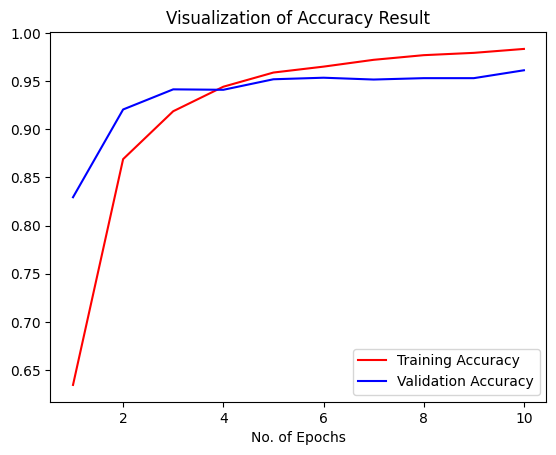

In [32]:
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Using the Saved Model

In [60]:
from tensorflow.keras.models import load_model

# cnn = load_model('trained_plant_disease_model.keras')
cnn = load_model('trained_plant_disease_model.keras',  compile=False)

## Other Mertics: 

In [33]:
class_name = validation_set.class_names
print(class_name)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [34]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17452 files belonging to 38 classes.


In [35]:
y_pred = cnn.predict(test_set)


17452/17452 ━━━━━━━━━━━━━━━━━━━━ 582s 33ms/step


In [36]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(17452,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17452,))>

In [37]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17452, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17452, 38), dtype=float32)>

In [38]:
y_true = tf.argmax(true_categories, axis=1)
y_true

<tf.Tensor: shape=(17452,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17452,))>

In [39]:
predicted_categories

<tf.Tensor: shape=(17452,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17452,))>

In [40]:
# y_true = tf.squeeze(true_categories).numpy().astype(int)
# y_true

In [41]:
!pip install scikit-learn

In [42]:
from sklearn.metrics import confusion_matrix,classification_report

In [43]:
# Precision Recall Fscore
print(classification_report(y_true,predicted_categories,target_names=class_name,zero_division=0))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.97      0.96       504
                                 Apple___Black_rot       0.97      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.96      0.98      0.97       440
                                   Apple___healthy       0.93      0.98      0.95       502
                               Blueberry___healthy       0.98      0.96      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.97      0.99      0.98       421
                 Cherry_(including_sour)___healthy       0.93      1.00      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.83      0.85       290
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.84      0.99      0.

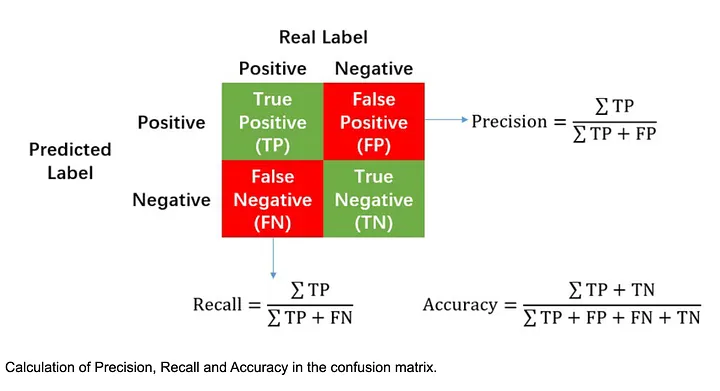

### Confusion Matrix Visualization

In [44]:
cm = confusion_matrix(y_true,predicted_categories)
cm

array([[489,   2,   0, ...,   0,   0,   0],
       [  1, 493,   0, ...,   0,   0,   0],
       [  1,   0, 431, ...,   1,   0,   0],
       ...,
       [  0,   0,   0, ..., 484,   0,   0],
       [  0,   0,   0, ...,   0, 444,   0],
       [  0,   0,   0, ...,   0,   0, 478]], shape=(38, 38))

In [45]:
cm.shape

(38, 38)

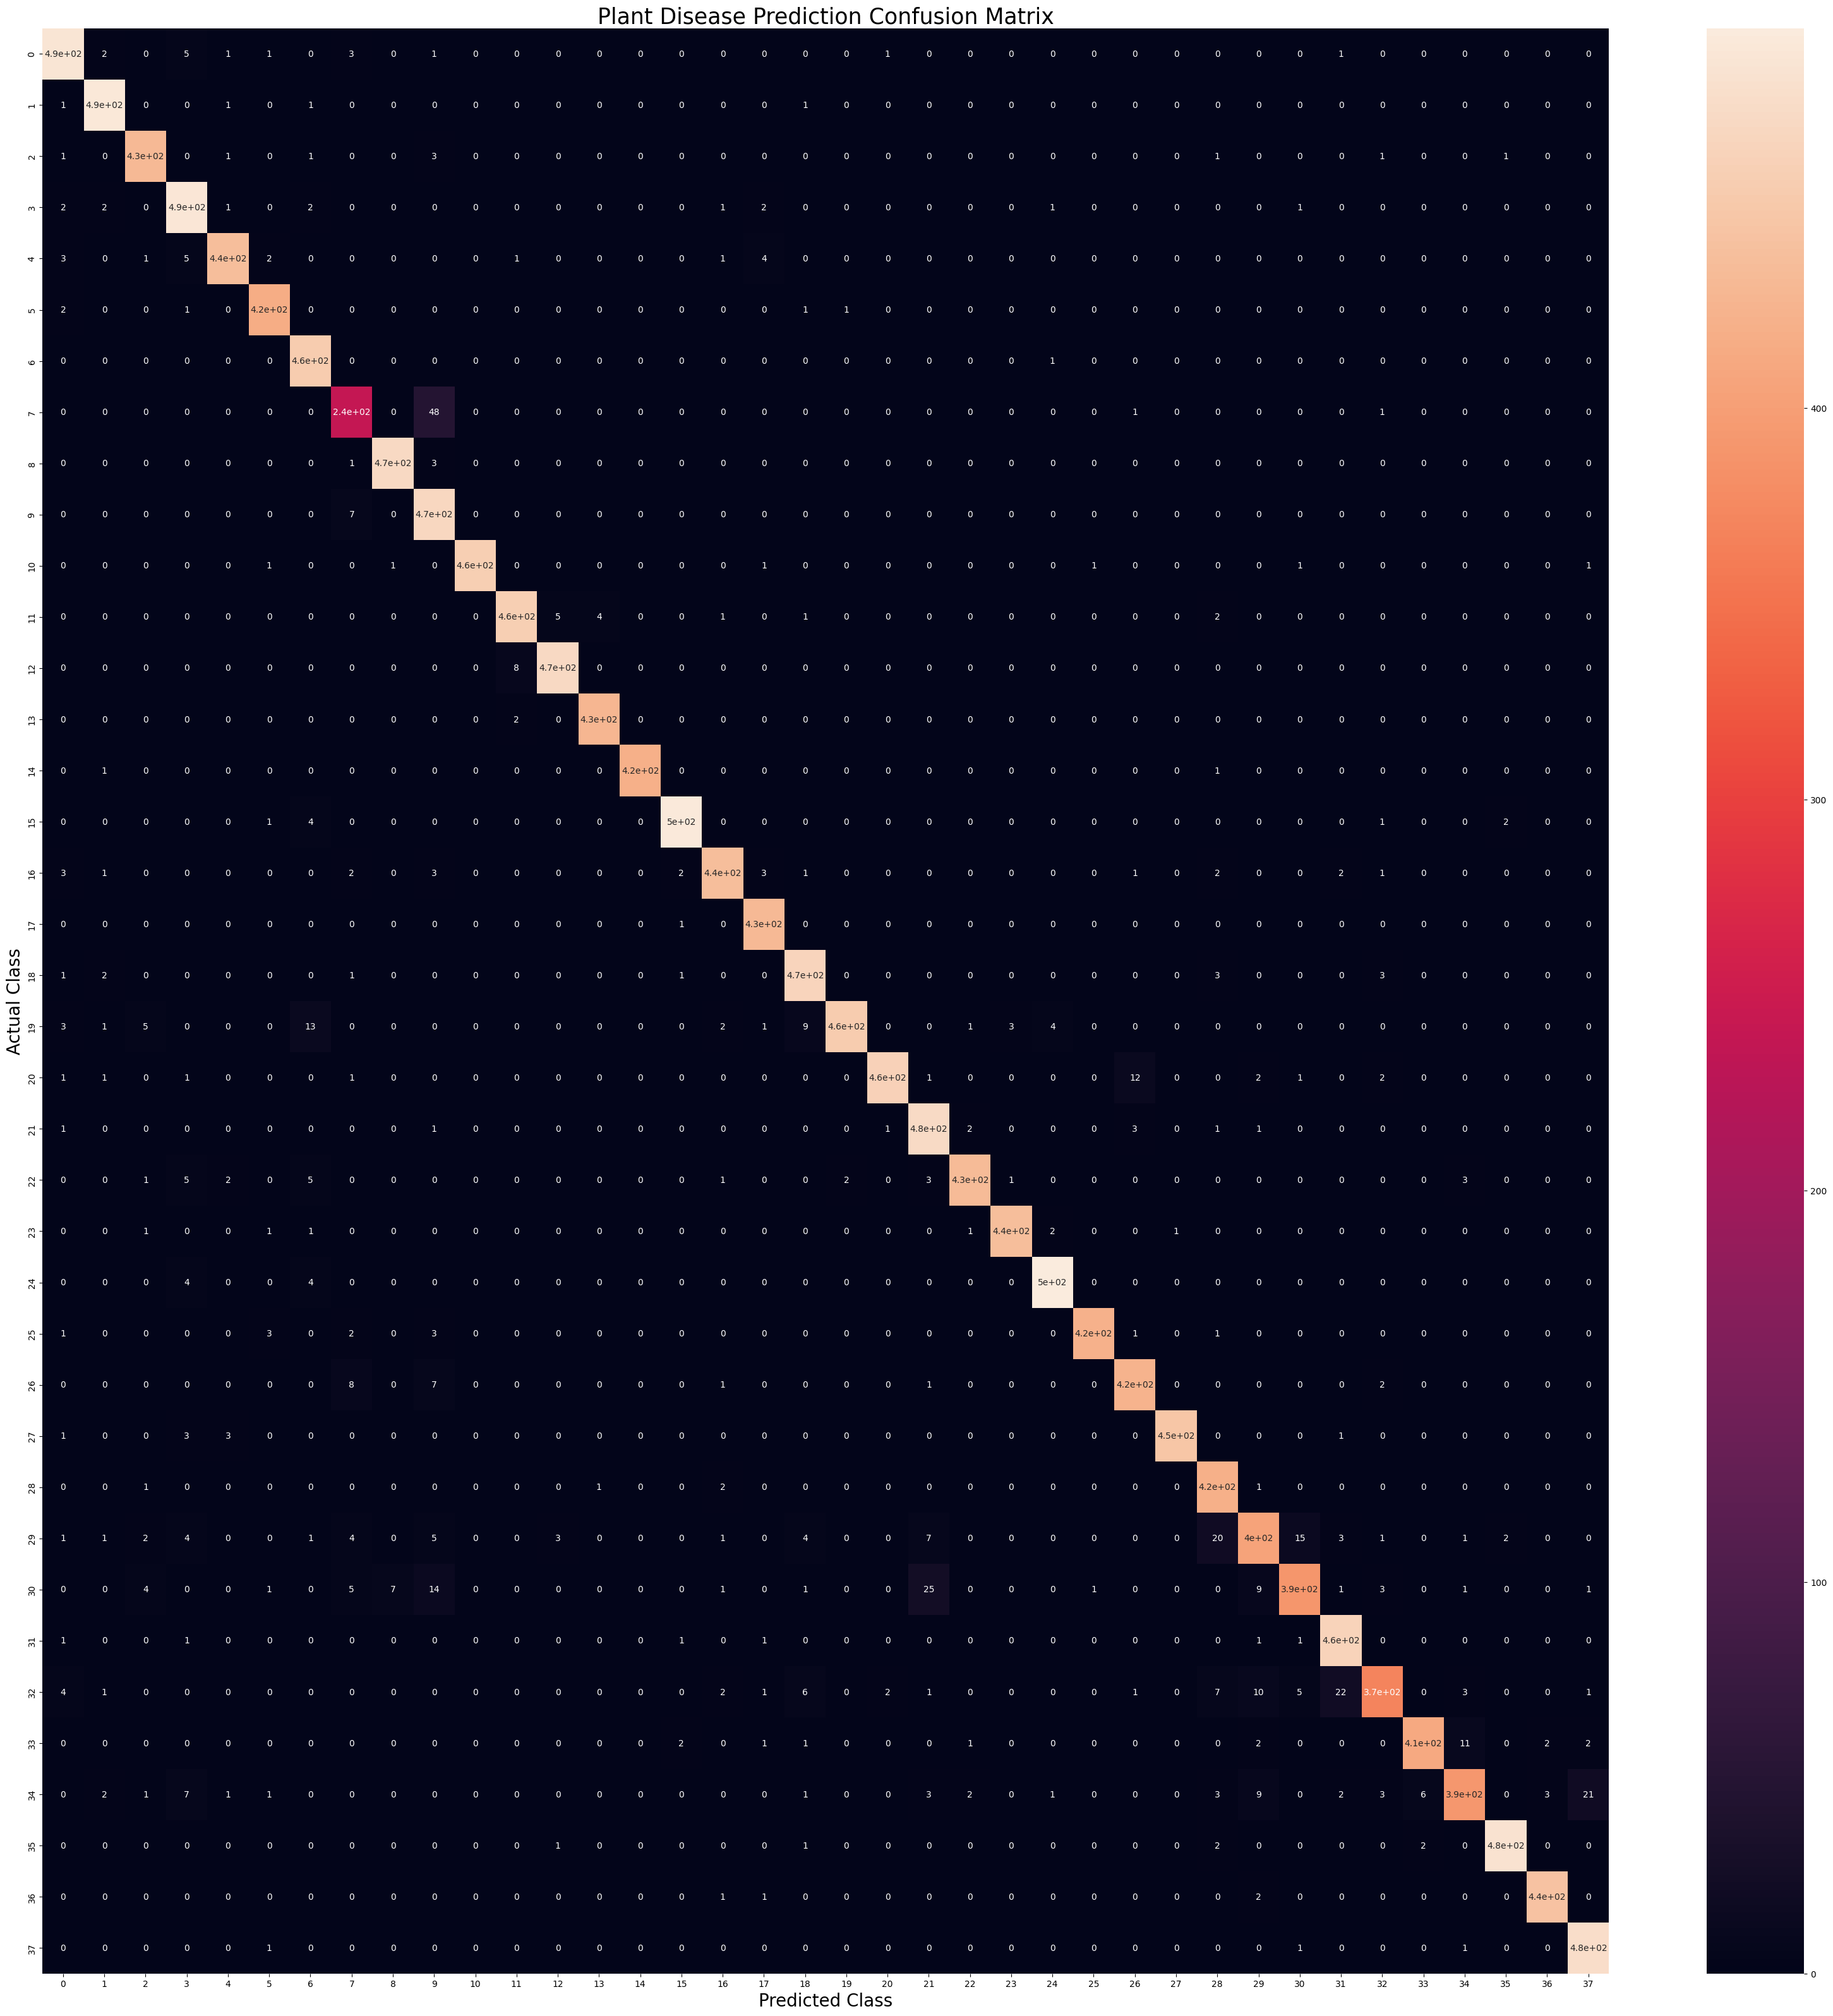

In [46]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()